# Spectral Similarity and Regime Anomalies on IEEE 118-Bus

Koopman spectra summarize the growth, decay, and oscillation rates represented
by a fitted linear operator. This notebook asks a focused question: **can
spectral distances distinguish selected changes in the simulated IEEE 118-bus
dynamics from ordinary noise variation?**

To make that comparison reproducible and scientifically interpretable, every
trajectory is fit with a deterministic rank-8 `DMDBaseline`. DMD operates in
the same flattened physical-state coordinates for every trajectory, avoiding
the arbitrary latent-coordinate rotations that arise when separately trained
neural encoders are compared.

The workflow is:

1. Generate three nominal reference trajectories and three parameter-shifted
   IEEE 118-bus trajectories.
2. Fit deterministic DMD operators and extract their spectra.
3. Build a pairwise **KoopSTD** distance matrix with `koopman_std`.
4. Cluster trajectories hierarchically from that matrix and map them to regime
   groups (dendrogram + MDS embedding).
5. Calibrate a threshold with `calibrate_anomaly_threshold` (percentile of
   nominal pairwise distances) and test which parameter shifts exceed it.

This is a controlled API demonstration, not evidence that the threshold will
generalize to measured power-grid data.

In [1]:
import warnings
from tqdm.std import TqdmWarning

warnings.filterwarnings('ignore', category=TqdmWarning)

import os

import matplotlib

if os.environ.get('PYTEST_CURRENT_TEST'):
    matplotlib.use('Agg')

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get('PYTEST_CURRENT_TEST'):
        get_ipython().run_line_magic('matplotlib', 'inline')
except (ImportError, NameError):
    pass

from koopman_graph import (
    DMDBaseline,
    calibrate_anomaly_threshold,
    detect_anomaly,
    koopman_std,
    spectrum_distance,
)
from koopman_graph.datasets import IEEE118DynamicBenchmark


## 1. Reference and parameter-shifted trajectories

The three nominal references share physical parameters but use different noise
seeds. Their pairwise distances estimate ordinary simulation variability. The
other trajectories isolate changes in load-ramp amplitude, diffusion rate, and
damping on the same 118-bus topology.

These are synthetic regimes from `IEEE118DynamicBenchmark`; labels such as
"strong damping" describe generator settings, not validated real-grid events.

In [2]:
REGIMES = {
    'nominal_a': dict(
        diffusion_rate=0.35, decay_rate=0.98, load_ramp_amplitude=0.10, seed=40
    ),
    'nominal_b': dict(
        diffusion_rate=0.35, decay_rate=0.98, load_ramp_amplitude=0.10, seed=41
    ),
    'nominal_c': dict(
        diffusion_rate=0.35, decay_rate=0.98, load_ramp_amplitude=0.10, seed=42
    ),
    'heavy_load': dict(
        diffusion_rate=0.35, decay_rate=0.98, load_ramp_amplitude=0.35, seed=42
    ),
    'fast_diffusion': dict(
        diffusion_rate=0.75, decay_rate=0.98, load_ramp_amplitude=0.10, seed=42
    ),
    'strong_damping': dict(
        diffusion_rate=0.35, decay_rate=0.70, load_ramp_amplitude=0.10, seed=42
    ),
}

sequences = {
    name: IEEE118DynamicBenchmark.generate(
        num_timesteps=60,
        noise_std=0.001,
        **params,
    )
    for name, params in REGIMES.items()
}

list(sequences)

['nominal_a',
 'nominal_b',
 'nominal_c',
 'heavy_load',
 'fast_diffusion',
 'strong_damping']

## 2. Fit deterministic operators in shared coordinates

A rank-8 DMD fit is deterministic and uses the same flattened node-feature
coordinate system for all trajectories. The rank truncation regularizes the
fit because 60 temporal snapshots are far fewer than the 472 physical state
variables (118 buses × 4 features).

The resulting spectra characterize these fitted finite-dimensional operators;
they should not be interpreted as exact spectra of a real transmission grid.

In [3]:
DMD_RANK = 8

models = {
    name: DMDBaseline(rank=DMD_RANK).fit(sequence)
    for name, sequence in sequences.items()
}
spectra = {name: model.spectrum() for name, model in models.items()}

# Only the leading modes are shown; rank truncation leaves the remaining
# flattened-state eigenvalues numerically near zero.
spectra['nominal_a'].magnitudes[:DMD_RANK]

tensor([0.9749, 0.9676, 0.9524, 0.9320, 0.8539, 0.7377, 0.5248, 0.3777])

## 3. Pairwise KoopSTD distance matrix

`koopman_std` builds a symmetric matrix of Wasserstein-1 distances between the
sorted eigenvalue-magnitude distributions. The diagonal must be zero. In this
controlled example, the three nominal replicates should form a tight block;
parameter shifts may sit farther away depending on how strongly they alter the
fitted spectrum.

The metric compares magnitudes only: it deliberately ignores eigenvalue phase,
eigenvector direction, and forecast accuracy.

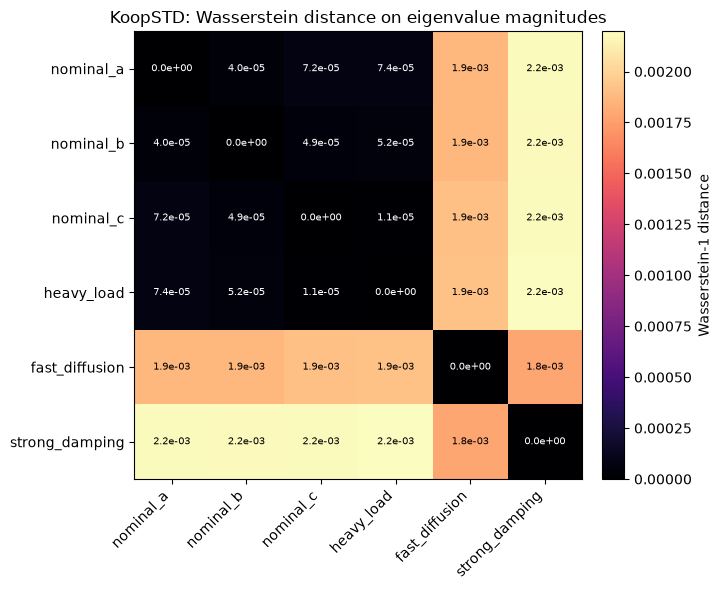

tensor([[0.0000e+00, 3.9595e-05, 7.2011e-05, 7.4354e-05, 1.8635e-03, 2.1851e-03],
        [3.9595e-05, 0.0000e+00, 4.8806e-05, 5.1536e-05, 1.8690e-03, 2.1736e-03],
        [7.2011e-05, 4.8806e-05, 0.0000e+00, 1.1097e-05, 1.9072e-03, 2.1860e-03],
        [7.4354e-05, 5.1536e-05, 1.1097e-05, 0.0000e+00, 1.9153e-03, 2.1971e-03],
        [1.8635e-03, 1.8690e-03, 1.9072e-03, 1.9153e-03, 0.0000e+00, 1.7895e-03],
        [2.1851e-03, 2.1736e-03, 2.1860e-03, 2.1971e-03, 1.7895e-03, 0.0000e+00]],
       dtype=torch.float64)

In [4]:
labels = list(spectra)
distance_matrix = koopman_std(
    [spectra[name] for name in labels],
    method='wasserstein',
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(distance_matrix.numpy(), cmap='magma')
ax.set_xticks(range(len(labels)), labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels)), labels)
ax.set_title('KoopSTD: Wasserstein distance on eigenvalue magnitudes')
for row in range(len(labels)):
    for col in range(len(labels)):
        ax.text(
            col,
            row,
            f'{distance_matrix[row, col]:.1e}',
            ha='center',
            va='center',
            color='white' if distance_matrix[row, col] < distance_matrix.max() / 2 else 'black',
            fontsize=7,
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Wasserstein-1 distance')
plt.tight_layout()
plt.show()

distance_matrix

## 4. Hierarchical clustering on KoopSTD distances

When more than two regimes are available, the full distance matrix supports
unsupervised grouping: trajectories with similar Koopman spectra cluster
together, separating ordinary within-regime variability from structurally distinct
dynamics.

Average-linkage hierarchical clustering on condensed Wasserstein distances
builds a dendrogram. A cutoff set to 1.5× the maximum nominal-replicate
distance groups trajectories without hand-picking the number of clusters.

A classical MDS embedding and dendrogram-ordered heatmap visualize how
trajectories map to regime groups. Clustering complements the binary threshold
test in Section 6: it reveals *how many* distinct dynamical regimes are
present, not just whether a single test trajectory is an outlier.

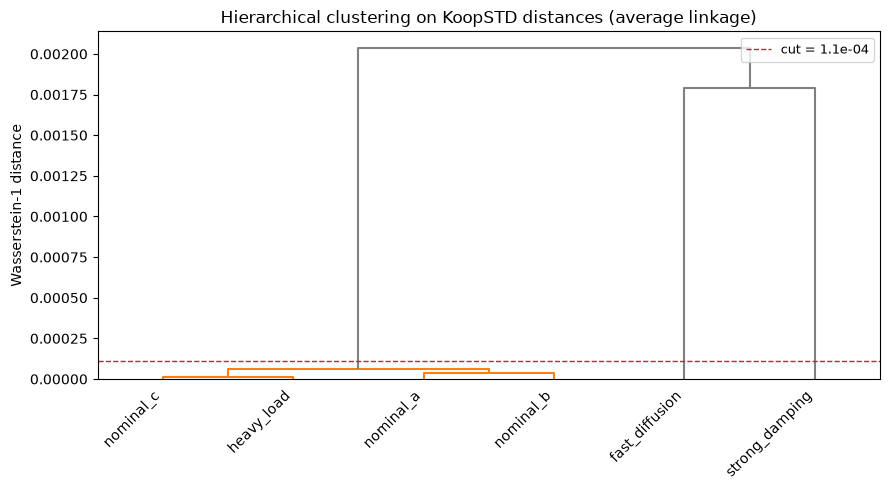

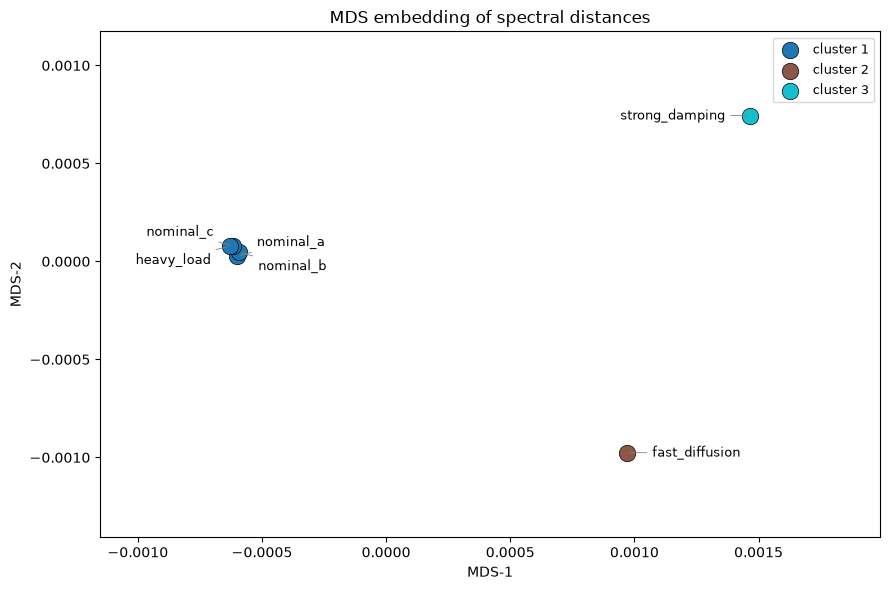

Cluster threshold (1.5× max nominal distance): 1.080e-04
nominal_a        kind=nominal  cluster=1
nominal_b        kind=nominal  cluster=1
nominal_c        kind=nominal  cluster=1
heavy_load       kind=shifted  cluster=1
fast_diffusion   kind=shifted  cluster=2
strong_damping   kind=shifted  cluster=3


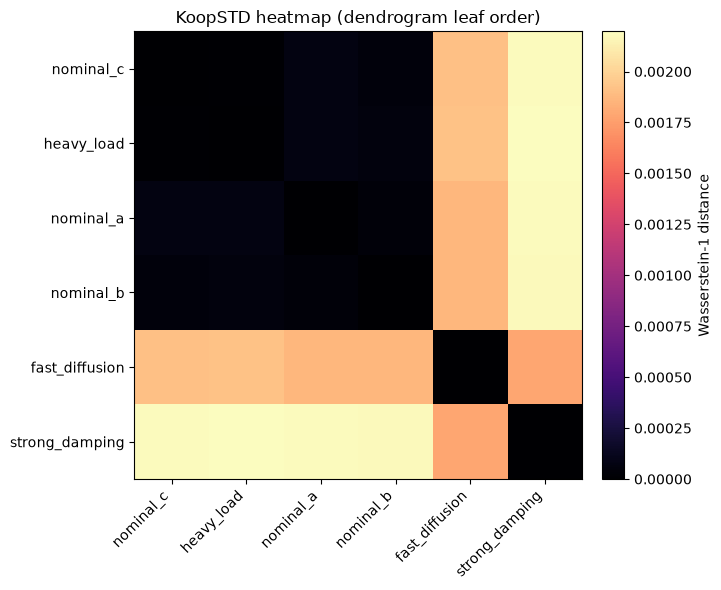

In [5]:
NOMINAL_LABELS = {'nominal_a', 'nominal_b', 'nominal_c'}
regime_kind = {
    name: 'nominal' if name in NOMINAL_LABELS else 'shifted'
    for name in labels
}

condensed = squareform(distance_matrix.numpy(), checks=False)
linkage_matrix = linkage(condensed, method='average')

nominal_indices = [labels.index(name) for name in NOMINAL_LABELS]
nominal_submatrix = distance_matrix.numpy()[np.ix_(nominal_indices, nominal_indices)]
upper_nominal = nominal_submatrix[
    np.triu(np.ones_like(nominal_submatrix, dtype=bool), k=1)
]
max_nominal_distance = upper_nominal.max()
cluster_threshold = 1.5 * max_nominal_distance

cluster_ids = fcluster(linkage_matrix, t=cluster_threshold, criterion='distance')
cluster_map = {name: int(cluster_id) for name, cluster_id in zip(labels, cluster_ids)}

fig, ax = plt.subplots(figsize=(9, 5))
dend = dendrogram(
    linkage_matrix,
    labels=labels,
    ax=ax,
    color_threshold=cluster_threshold,
    above_threshold_color='grey',
    leaf_rotation=45,
    leaf_font_size=10,
)
ax.axhline(
    cluster_threshold,
    color='crimson',
    linestyle='--',
    linewidth=1,
    label=f'cut = {cluster_threshold:.1e}',
)
ax.set_title('Hierarchical clustering on KoopSTD distances (average linkage)')
ax.set_ylabel('Wasserstein-1 distance')
ax.legend(fontsize=9)
for tick in ax.get_xticklabels():
    tick.set_ha('right')
plt.tight_layout()
plt.show()

n = len(labels)
D = distance_matrix.numpy()
centering = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * centering @ (D**2) @ centering
evals, evecs = np.linalg.eigh(B)
leading = np.argsort(evals)[::-1][:2]
coords = evecs[:, leading] * np.sqrt(np.maximum(evals[leading], 0.0))

# Fan label offsets around each point so near-coincident trajectories (the
# nominal replicates and heavy_load) stay individually readable.
offsets = [(14, 10), (14, -10), (-14, 10), (-14, -10), (18, 0), (-18, 0)]

fig, ax = plt.subplots(figsize=(9, 6))
unique_clusters = sorted(set(cluster_ids))
palette = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
for cluster_id, color in zip(unique_clusters, palette):
    members = [index for index, cid in enumerate(cluster_ids) if cid == cluster_id]
    ax.scatter(
        coords[members, 0],
        coords[members, 1],
        s=140,
        c=[color],
        label=f'cluster {cluster_id}',
        edgecolors='black',
        linewidths=0.5,
        zorder=3,
    )
for index, name in enumerate(labels):
    ax.annotate(
        name,
        (coords[index, 0], coords[index, 1]),
        xytext=offsets[index % len(offsets)],
        textcoords='offset points',
        fontsize=9,
        ha='left' if offsets[index % len(offsets)][0] >= 0 else 'right',
        va='center',
        arrowprops=dict(arrowstyle='-', color='grey', linewidth=0.6),
    )
ax.margins(0.25)
ax.set_title('MDS embedding of spectral distances')
ax.set_xlabel('MDS-1')
ax.set_ylabel('MDS-2')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

print(f'Cluster threshold (1.5× max nominal distance): {cluster_threshold:.3e}')
for name in labels:
    print(
        f'{name:16s} kind={regime_kind[name]:8s} '
        f'cluster={cluster_map[name]}'
    )

leaf_order = dend['leaves']
ordered_labels = [labels[index] for index in leaf_order]
ordered_matrix = distance_matrix.numpy()[np.ix_(leaf_order, leaf_order)]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(ordered_matrix, cmap='magma')
ax.set_xticks(range(len(ordered_labels)), ordered_labels, rotation=45, ha='right')
ax.set_yticks(range(len(ordered_labels)), ordered_labels)
ax.set_title('KoopSTD heatmap (dendrogram leaf order)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Wasserstein-1 distance')
plt.tight_layout()
plt.show()

## 5. Subspace-angle comparison

Wasserstein distance compares eigenvalue *magnitudes*. Principal subspace angle
compares the span of leading eigenvector *directions*. Because all DMD operators
act on the same flattened physical coordinates, this eigenvector comparison is
well-defined here.

It would not be invariant to arbitrary latent-coordinate rotations between
separately trained neural encoders. The two metrics answer different questions;
this example reports both without claiming that either alone measures physical
severity.

In [6]:
comparisons = ['nominal_b', 'heavy_load', 'fast_diffusion', 'strong_damping']
for name in comparisons:
    magnitude_distance = spectrum_distance(
        spectra['nominal_a'],
        spectra[name],
        method='wasserstein',
    )
    subspace_angle = spectrum_distance(
        spectra['nominal_a'],
        spectra[name],
        method='subspace_angle',
        num_modes=3,
    )
    print(
        f'nominal_a vs {name:14s}: '
        f'W1={magnitude_distance.item():.3e}, '
        f'top-3 angle={subspace_angle.item():.3f} rad'
    )

nominal_a vs nominal_b     : W1=3.959e-05, top-3 angle=0.035 rad
nominal_a vs heavy_load    : W1=7.435e-05, top-3 angle=0.105 rad
nominal_a vs fast_diffusion: W1=1.863e-03, top-3 angle=0.200 rad
nominal_a vs strong_damping: W1=2.185e-03, top-3 angle=0.968 rad


## 6. Thresholded anomaly demonstration

`detect_anomaly` requires an explicit threshold. Here it is derived with
`calibrate_anomaly_threshold(..., method="percentile", q=95)` from pairwise
Wasserstein distances among the three nominal replicates — the 95th percentile
of in-distribution reference spread.

The threshold is specific to this simulator, DMD rank, metric, trajectory
length, and noise level. It is not a statistically validated operating limit,
and a result below threshold means only "spectrally similar under this test" —
not "physically safe."

In [7]:
reference_names = ['nominal_a', 'nominal_b', 'nominal_c']
reference_spectra = [spectra[name] for name in reference_names]
threshold = calibrate_anomaly_threshold(
    reference_spectra,
    method='percentile',
    distance_method='wasserstein',
    q=95,
)

print(
    'Calibrated threshold (95th percentile of nominal pairwise distances): '
    f'{threshold:.3e}\n'
)

for name in ['heavy_load', 'fast_diffusion', 'strong_damping']:
    result = detect_anomaly(
        reference_spectra,
        spectra[name],
        threshold=threshold,
        method='wasserstein',
    )
    print(
        f'{name:14s}: anomaly={result.is_anomaly!s:5s}, '
        f'mean reference distance={result.distance:.3e}'
    )

Calibrated threshold (95th percentile of nominal pairwise distances): 6.969e-05

heavy_load    : anomaly=False, mean reference distance=4.566e-05
fast_diffusion: anomaly=True , mean reference distance=1.880e-03
strong_damping: anomaly=True , mean reference distance=2.182e-03


## Takeaways

- Hierarchical clustering on the KoopSTD matrix groups the three nominal
  replicates with the modest load-ramp shift, while faster diffusion and stronger
  damping form separate regime clusters — a multi-regime view that complements
  the binary anomaly flags in Section 6.
- The three nominal replicates establish a reproducible within-regime distance
  scale. In this configured run, the fast-diffusion and strong-damping shifts
  exceed the threshold; the load-ramp change does not.
- Wasserstein magnitude distance and principal subspace angle describe different
  spectral properties. Neither is a direct measure of forecast error, physical
  severity, or grid safety.
- The shared physical coordinates of DMD make eigenvector-subspace comparison
  meaningful. Comparing eigenvectors from independently trained neural latent
  spaces would require an explicit alignment step.
- `calibrate_anomaly_threshold` summarizes reference pairwise distances
  (`percentile` or `mean_std`); `detect_anomaly` only applies the resulting
  rule. Real monitoring still needs held-out nominal and fault data,
  uncertainty analysis, and domain-specific validation.
